<a href="https://colab.research.google.com/github/DanieldeSSilva/Curso-python/blob/main/Redu%C3%A7%C3%A3o_de_dimensionalidade.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

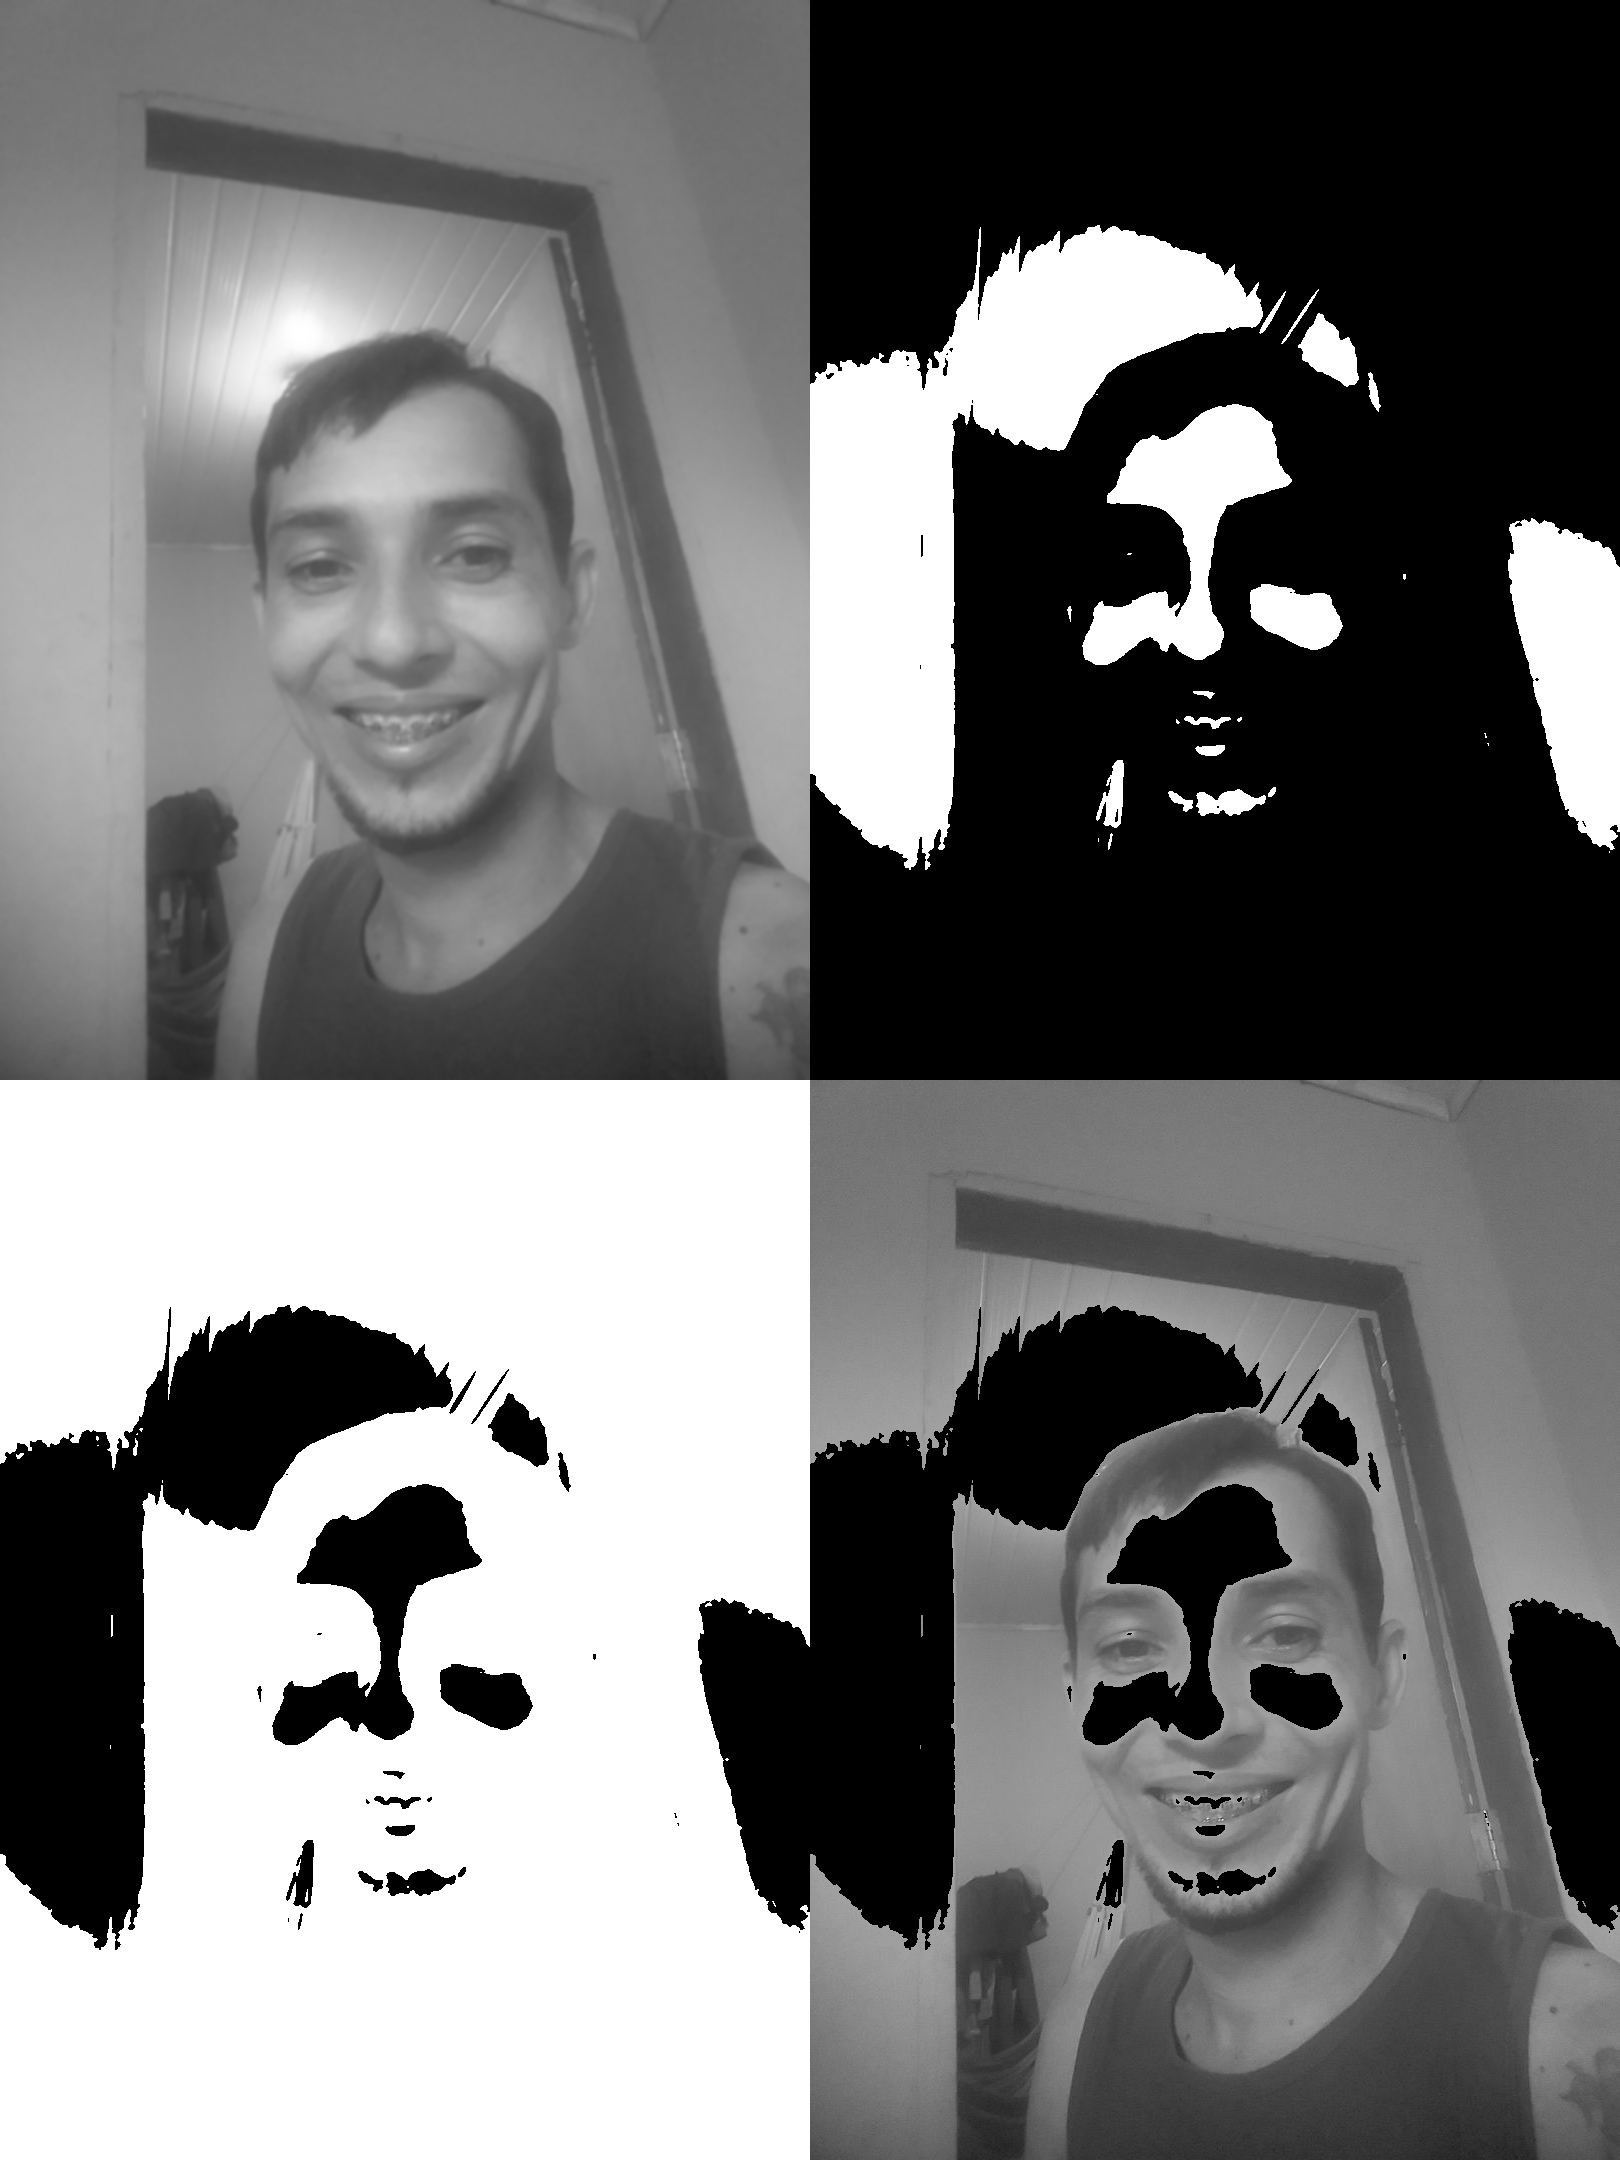

In [36]:
import numpy as np
import cv2
from google.colab.patches import cv2_imshow

# Carregar a imagem e verificar se foi carregada corretamente
img = cv2.imread("ME.jpg")
# cv2_imshow(img)  # Descomente esta linha se quiser visualizar a imagem carregada inicialmente
if img is None:
    # Exibir mensagem de erro caso a imagem não seja encontrada ou carregada
    print("Erro: Não foi possível carregar a imagem. Verifique o caminho e o nome do arquivo.")
else:
    # Converter a imagem para escala de cinza
    img = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

    # Aplicar um filtro de desfoque Gaussiano para suavizar a imagem
    suave = cv2.GaussianBlur(img, (7, 7), 0)

    # Aplicar a técnica de limiarização binária à imagem suavizada
    (t, bin) = cv2.threshold(suave, 160, 255, cv2.THRESH_BINARY)

    # Aplicar a técnica de limiarização binária invertida à imagem suavizada
    (t, binI) = cv2.threshold(suave, 160, 255, cv2.THRESH_BINARY_INV)

    # Combinar as imagens resultantes em uma única imagem para visualização
    resultado = np.vstack([
        np.hstack([suave, bin]),  # Combinar imagens lado a lado (horizontalmente)
        np.hstack([binI, cv2.bitwise_and(img, img, mask=binI)])  # Combinar lado a lado com a imagem resultante da operação bitwise AND
    ])

    # Mostrar a imagem resultante usando cv2_imshow no Google Colab
    cv2_imshow(resultado)  # Usar cv2_imshow em vez de cv2.imshow
    cv2.waitKey(0)  # Esperar até que uma tecla seja pressionada
    cv2.destroyAllWindows()  # Fechar todas as janelas abertas pelo OpenCV

